In [1]:
!pip install -q tensorflow opencv-python matplotlib seaborn scikit-learn

In [4]:
!kaggle datasets download -d andrewmvd/face-mask-detection
!unzip -q face-mask-detection.zip -d /content/dataset

import os
print(os.listdir("/content/dataset"))
print("Images:", len(os.listdir("/content/dataset/images")))
print("Annotations:", len(os.listdir("/content/dataset/annotations")))

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/face-mask-detection
License(s): CC0-1.0
100% 398M/398M [00:10<00:00, 38.0MB/s]

['annotations', 'images']
Images: 853
Annotations: 853


In [5]:
import os
import xml.etree.ElementTree as ET
from PIL import Image

IMAGES_DIR = "/content/dataset/images"
ANNOTATIONS_DIR = "/content/dataset/annotations"
OUTPUT_DIR = "/content/cropped_faces"

LABEL_MAP = {
    "with_mask": "mask_proper",
    "without_mask": "no_mask",
    "mask_weared_incorrect": "mask_improper"
}

for folder in LABEL_MAP.values():
    os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)

class_counts = {folder: 0 for folder in LABEL_MAP.values()}
skipped = 0

for xml_file in os.listdir(ANNOTATIONS_DIR):
    if not xml_file.endswith(".xml"):
        continue

    xml_path = os.path.join(ANNOTATIONS_DIR, xml_file)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    img_path = os.path.join(IMAGES_DIR, filename)

    if not os.path.exists(img_path):
        skipped += 1
        continue

    img = Image.open(img_path).convert("RGB")
    img_w, img_h = img.size

    for i, obj in enumerate(root.findall("object")):
        raw_label = obj.find("n").text if obj.find("n") is not None else obj.find("name").text
        if raw_label not in LABEL_MAP:
            continue
        clean_label = LABEL_MAP[raw_label]

        bnd = obj.find("bndbox")
        xmin = max(0, int(bnd.find("xmin").text))
        ymin = max(0, int(bnd.find("ymin").text))
        xmax = min(img_w, int(bnd.find("xmax").text))
        ymax = min(img_h, int(bnd.find("ymax").text))

        # skip degenerate boxes
        if xmax <= xmin or ymax <= ymin:
            continue

        face_crop = img.crop((xmin, ymin, xmax, ymax))

        base_name = os.path.splitext(filename)[0]
        save_path = os.path.join(OUTPUT_DIR, clean_label, f"{base_name}_{i}.png")
        face_crop.save(save_path)
        class_counts[clean_label] += 1

print("Skipped (image not found):", skipped)
print("Class counts after cropping:")
for cls, count in class_counts.items():
    print(f"  {cls}: {count}")
print("Total faces:", sum(class_counts.values()))

Skipped (image not found): 0
Class counts after cropping:
  mask_proper: 3232
  no_mask: 717
  mask_improper: 123
Total faces: 4072


In [6]:
import os
import shutil
import random

random.seed(42)

SRC_DIR = "/content/cropped_faces"
SPLIT_DIR = "/content/split_data"
CLASSES = ["mask_proper", "mask_improper", "no_mask"]
SPLITS = {"train": 0.70, "val": 0.15, "test": 0.15}

for split in SPLITS:
    for cls in CLASSES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

for cls in CLASSES:
    files = os.listdir(os.path.join(SRC_DIR, cls))
    random.shuffle(files)

    n = len(files)
    n_train = int(n * SPLITS["train"])
    n_val = int(n * SPLITS["val"])

    split_map = {
        "train": files[:n_train],
        "val": files[n_train:n_train + n_val],
        "test": files[n_train + n_val:]
    }

    for split, split_files in split_map.items():
        for f in split_files:
            src = os.path.join(SRC_DIR, cls, f)
            dst = os.path.join(SPLIT_DIR, split, cls, f)
            shutil.copy(src, dst)

    print(f"{cls}: train={len(split_map['train'])}, val={len(split_map['val'])}, test={len(split_map['test'])}")

mask_proper: train=2262, val=484, test=486
mask_improper: train=86, val=18, test=19
no_mask: train=501, val=107, test=109


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img, load_img
import os

TRAIN_DIR = "/content/split_data/train"
CLASSES = ["mask_proper", "mask_improper", "no_mask"]
AUG_MULTIPLIER = {
    "mask_proper": 0,
    "no_mask": 2,
    "mask_improper": 15
}

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

for cls in CLASSES:
    multiplier = AUG_MULTIPLIER[cls]
    if multiplier == 0:
        continue

    cls_dir = os.path.join(TRAIN_DIR, cls)
    original_files = [f for f in os.listdir(cls_dir) if not f.startswith("aug_")]

    for fname in original_files:
        img_path = os.path.join(cls_dir, fname)
        img = load_img(img_path)
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)

        i = 0
        for batch in datagen.flow(x, batch_size=1):
            aug_img = array_to_img(batch[0])
            base_name = os.path.splitext(fname)[0]
            aug_img.save(os.path.join(cls_dir, f"aug_{base_name}_{i}.png"))
            i += 1
            if i >= multiplier:
                break

for cls in CLASSES:
    count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"{cls} (train, after augmentation): {count}")

mask_proper (train, after augmentation): 2262
mask_improper (train, after augmentation): 1376
no_mask (train, after augmentation): 1503


In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

IMG_SIZE = 128

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    "/content/split_data/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    "/content/split_data/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

labels = train_gen.classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Found 5141 images belonging to 3 classes.
Found 609 images belonging to 3 classes.
Class indices: {'mask_improper': 0, 'mask_proper': 1, 'no_mask': 2}
Class weights: {0: np.float64(1.2453972868217054), 1: np.float64(0.7575891541408782), 2: np.float64(1.1401641162120204)}


In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

EPOCHS = 25

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("best_mask_model.h5", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/25
159/161 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4698 - loss: 1.1281

161/161 ━━━━━━━━━━━━━━━━━━━━ 53s 217ms/step - accuracy: 0.5656 - loss: 0.9503 - val_accuracy: 0.6519 - val_loss: 0.7838 - learning_rate: 1.0000e-04
Epoch 2/25
160/161 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6953 - loss: 0.6975

161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.7146 - loss: 0.6680 - val_accuracy: 0.7635 - val_loss: 0.6054 - learning_rate: 1.0000e-04
Epoch 3/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7716 - loss: 0.5780

161/161 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.7746 - loss: 0.5668 - val_accuracy: 0.7882 - val_loss: 0.5346 - learning_rate: 1.0000e-04
Epoch 4/25
159/161 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7989 - loss: 0.4969

161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.8068 - loss: 0.4937 - val_accuracy: 0.8243 - val_loss: 0.4531 - learning_rate: 1.0000e-04
Epoch 5/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8325 - loss: 0.4451 - val_accuracy: 0.8095 - val_loss: 0.4722 - learning_rate: 1.0000e-04
Epoch 6/25
159/161 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8408 - loss: 0.4161

...

161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8697 - loss: 0.3491 - val_accuracy: 0.8604 - val_loss: 0.3667 - learning_rate: 1.0000e-04
Epoch 9/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8800 - loss: 0.3301 - val_accuracy: 0.8391 - val_loss: 0.3860 - learning_rate: 1.0000e-04
Epoch 10/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.8872 - loss: 0.3135 - val_accuracy: 0.8424 - val_loss: 0.3802 - learning_rate: 1.0000e-04
Epoch 11/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8849 - loss: 0.2985

161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8961 - loss: 0.2851 - val_accuracy: 0.8571 - val_loss: 0.3496 - learning_rate: 1.0000e-04
Epoch 12/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8985 - loss: 0.2749 - val_accuracy: 0.8456 - val_loss: 0.3651 - learning_rate: 1.0000e-04
Epoch 13/25
160/161 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9121 - loss: 0.2634

161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9099 - loss: 0.2579 - val_accuracy: 0.8621 - val_loss: 0.3364 - learning_rate: 1.0000e-04
Epoch 14/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9132 - loss: 0.2492 - val_accuracy: 0.8276 - val_loss: 0.4004 - learning_rate: 1.0000e-04
Epoch 15/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9197 - loss: 0.2321 - val_accuracy: 0.8555 - val_loss: 0.3451 - learning_rate: 1.0000e-04
Epoch 16/25
160/161 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9227 - loss: 0.2223

161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9204 - loss: 0.2244 - val_accuracy: 0.8736 - val_loss: 0.3090 - learning_rate: 1.0000e-04
Epoch 17/25
160/161 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9254 - loss: 0.2184

161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9234 - loss: 0.2163 - val_accuracy: 0.8768 - val_loss: 0.3048 - learning_rate: 1.0000e-04
Epoch 18/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9271 - loss: 0.2060 - val_accuracy: 0.8686 - val_loss: 0.3241 - learning_rate: 1.0000e-04
Epoch 19/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9319 - loss: 0.2035 - val_accuracy: 0.8719 - val_loss: 0.3136 - learning_rate: 1.0000e-04
Epoch 20/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9362 - loss: 0.1860 - val_accuracy: 0.8670 - val_loss: 0.3267 - learning_rate: 1.0000e-04
Epoch 21/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9442 - loss: 0.1752 - val_accuracy: 0.8703 - val_loss: 0.3161 - learning_rate: 5.0000e-05
Epoch 22/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9422 - loss: 0.1731 - val_accuracy: 0.8654 - val_loss: 0.3219 - learning_rate: 5.0000e-05


In [11]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    "/content/split_data/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False  # important: keep order so predictions line up with true labels later
)

test_loss, test_accuracy = model.evaluate(test_gen)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Found 614 images belonging to 3 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 624ms/step - accuracy: 0.8827 - loss: 0.3258
Test Loss: 0.3258
Test Accuracy: 88.27%


In [12]:
import tensorflow as tf
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Trainable layers:",
      sum(layer.trainable for layer in base_model.layers))

print("Total layers:",
      len(base_model.layers))

Trainable layers: 19
Total layers: 154


In [13]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model recompiled.")
print(
    "Learning rate:",
    float(model.optimizer.learning_rate.numpy())
)

Model recompiled.
Learning rate: 9.999999747378752e-06


In [14]:

FINE_TUNE_EPOCHS = 10

fine_tune_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/10
160/161 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9204 - loss: 0.2165

161/161 ━━━━━━━━━━━━━━━━━━━━ 31s 116ms/step - accuracy: 0.9228 - loss: 0.2052 - val_accuracy: 0.8752 - val_loss: 0.2975 - learning_rate: 1.0000e-05
Epoch 2/10
160/161 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9413 - loss: 0.1700

161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9415 - loss: 0.1627 - val_accuracy: 0.8834 - val_loss: 0.2908 - learning_rate: 1.0000e-05
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9551 - loss: 0.1315 - val_accuracy: 0.8851 - val_loss: 0.3087 - learning_rate: 1.0000e-05
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9659 - loss: 0.1094

161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9599 - loss: 0.1159 - val_accuracy: 0.8949 - val_loss: 0.2803 - learning_rate: 1.0000e-05
Epoch 5/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9727 - loss: 0.0912

161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9716 - loss: 0.0910 - val_accuracy: 0.9015 - val_loss: 0.2738 - learning_rate: 1.0000e-05
Epoch 6/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9714 - loss: 0.0883 - val_accuracy: 0.8982 - val_loss: 0.2971 - learning_rate: 1.0000e-05
Epoch 7/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9782 - loss: 0.0702 - val_accuracy: 0.9015 - val_loss: 0.2806 - learning_rate: 1.0000e-05
Epoch 8/10
160/161 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9765 - loss: 0.0743

161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9772 - loss: 0.0727 - val_accuracy: 0.9130 - val_loss: 0.2687 - learning_rate: 1.0000e-05
Epoch 9/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9864 - loss: 0.0486 - val_accuracy: 0.9195 - val_loss: 0.2707 - learning_rate: 1.0000e-05
Epoch 10/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9856 - loss: 0.0472 - val_accuracy: 0.9048 - val_loss: 0.2897 - learning_rate: 1.0000e-05


In [17]:
model.load_weights("best_mask_model.h5")



Best fine-tuned weights loaded.


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
               precision    recall  f1-score   support

mask_improper       0.50      0.32      0.39        19
  mask_proper       0.97      0.93      0.95       486
      no_mask       0.75      0.92      0.82       109

     accuracy                           0.91       614
    macro avg       0.74      0.72      0.72       614
 weighted avg       0.91      0.91      0.91       614



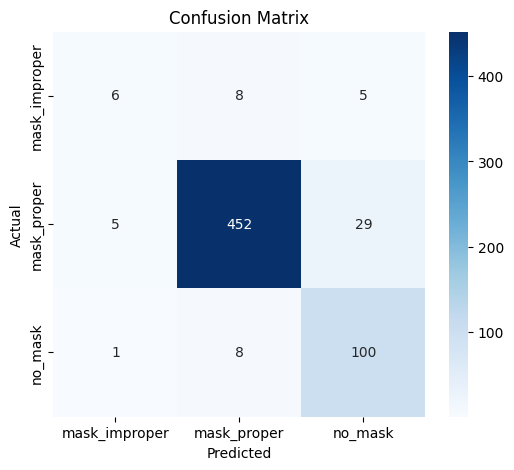

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

test_gen.reset()
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(test_gen.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

In [25]:
TRAIN_DIR = "/content/split_data/train"
cls = "mask_improper"
cls_dir = os.path.join(TRAIN_DIR, cls)

original_files = [f for f in os.listdir(cls_dir) if not f.startswith("aug_")]

datagen_v2 = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.7, 1.3],
    zoom_range=0.15,
    channel_shift_range=30.0,
    horizontal_flip=True,
    fill_mode="nearest"
)

EXTRA_MULTIPLIER = 10

for fname in original_files:
    img_path = os.path.join(cls_dir, fname)
    img = load_img(img_path)
    x = img_to_array(img)
    x = x.reshape((1,) + x.shape)
    i = 0
    for batch in datagen_v2.flow(x, batch_size=1):
        aug_img = array_to_img(batch[0])
        base_name = os.path.splitext(fname)[0]
        aug_img.save(os.path.join(cls_dir, f"augv2_{base_name}_{i}.png"))
        i += 1
        if i >= EXTRA_MULTIPLIER:
            break

print(f"{cls} (train, after boosted augmentation): {len(os.listdir(cls_dir))}")

mask_improper (train, after boosted augmentation): 2236


In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    "/content/split_data/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    "/content/split_data/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

labels = train_gen.classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Found 6001 images belonging to 3 classes.
Found 609 images belonging to 3 classes.
Class indices: {'mask_improper': 0, 'mask_proper': 1, 'no_mask': 2}
Class weights: {0: np.float64(0.8946034585569469), 1: np.float64(0.8843206601827291), 2: np.float64(1.3308937680195165)}


In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("best_mask_model.h5", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
]

EPOCHS_EXTRA = 8

history_boost = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_EXTRA,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/8
186/188 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9595 - loss: 0.1195

188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - accuracy: 0.9618 - loss: 0.1080 - val_accuracy: 0.8834 - val_loss: 0.3332 - learning_rate: 1.0000e-05
Epoch 2/8
187/188 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9703 - loss: 0.0853

188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9693 - loss: 0.0862 - val_accuracy: 0.9146 - val_loss: 0.2574 - learning_rate: 1.0000e-05
Epoch 3/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9833 - loss: 0.0589 - val_accuracy: 0.9097 - val_loss: 0.2817 - learning_rate: 1.0000e-05
Epoch 4/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9818 - loss: 0.0553 - val_accuracy: 0.8998 - val_loss: 0.3141 - learning_rate: 1.0000e-05
Epoch 5/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9870 - loss: 0.0412 - val_accuracy: 0.9080 - val_loss: 0.2814 - learning_rate: 1.0000e-05
Epoch 6/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9907 - loss: 0.0340 - val_accuracy: 0.9113 - val_loss: 0.2739 - learning_rate: 5.0000e-06
Epoch 7/8
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9947 - loss: 0.0252 - val_accuracy: 0.9212 - val_loss: 0.2701 - learning_rate: 5.0000e-06


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
               precision    recall  f1-score   support

mask_improper       0.38      0.42      0.40        19
  mask_proper       0.97      0.94      0.95       486
      no_mask       0.82      0.91      0.86       109

     accuracy                           0.92       614
    macro avg       0.72      0.76      0.74       614
 weighted avg       0.92      0.92      0.92       614



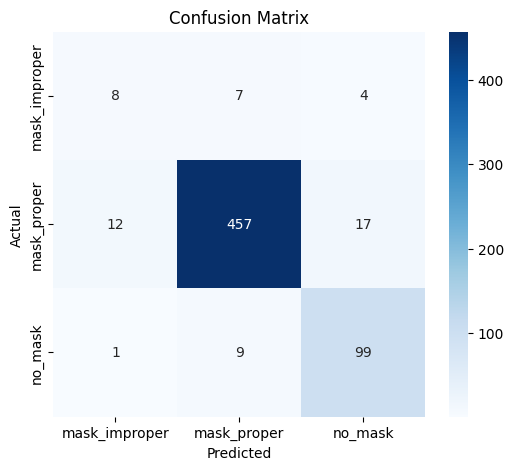

In [28]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

test_gen.reset()
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(test_gen.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

In [29]:
model.save("mask_detector_model.h5")
from google.colab import files
files.download("mask_detector_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>